# 🏗️ RAIL Practitioner Hub: Energy & Oil/Gas Edition
## Part 1: Identifying the "Static Gap"

---

### 📌 Overview
In the Energy sector, downtime costs millions. Traditional ML models are often trained on static "Historical Golden Datasets." However, offshore environments are dynamic. 

**The Problem:** When sensor signatures change due to atmospheric pressure, saltwater corrosion, or novel mechanical wear, static models experience a **Static Gap**—they become blind to emerging risks.

### 🧪 The Scenario
We are monitoring a **Centrifugal Pump** on an offshore rig. 
- **Training Data:** Recorded during ideal summer conditions.
- **Real-time Data:** Recorded during a winter storm with gradual bearing wear.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Premium Aesthetics
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")

# Load Historical Data
hist_df = pd.read_csv('../data/historical_rig_data.csv')

print(f"✅ Loaded {len(hist_df)} historical telemetry records.")

# Static Model: Defined by 3-Sigma limits from training data
temp_mean = hist_df['temperature'].mean()
temp_std = hist_df['temperature'].std()
temp_limit = temp_mean + (3 * temp_std)

print(f"📡 Static Threshold (3σ): {temp_limit:.2f}°C")

✅ Loaded 11 historical telemetry records.
📡 Static Threshold (3σ): 75.35°C


### ⚠️ Visualizing the Static Blindspot
Below, we see the real-time telemetry. Notice how the temperature gradually rises due to bearing friction (Drift). A static model only triggers an alarm when it's **too late**.

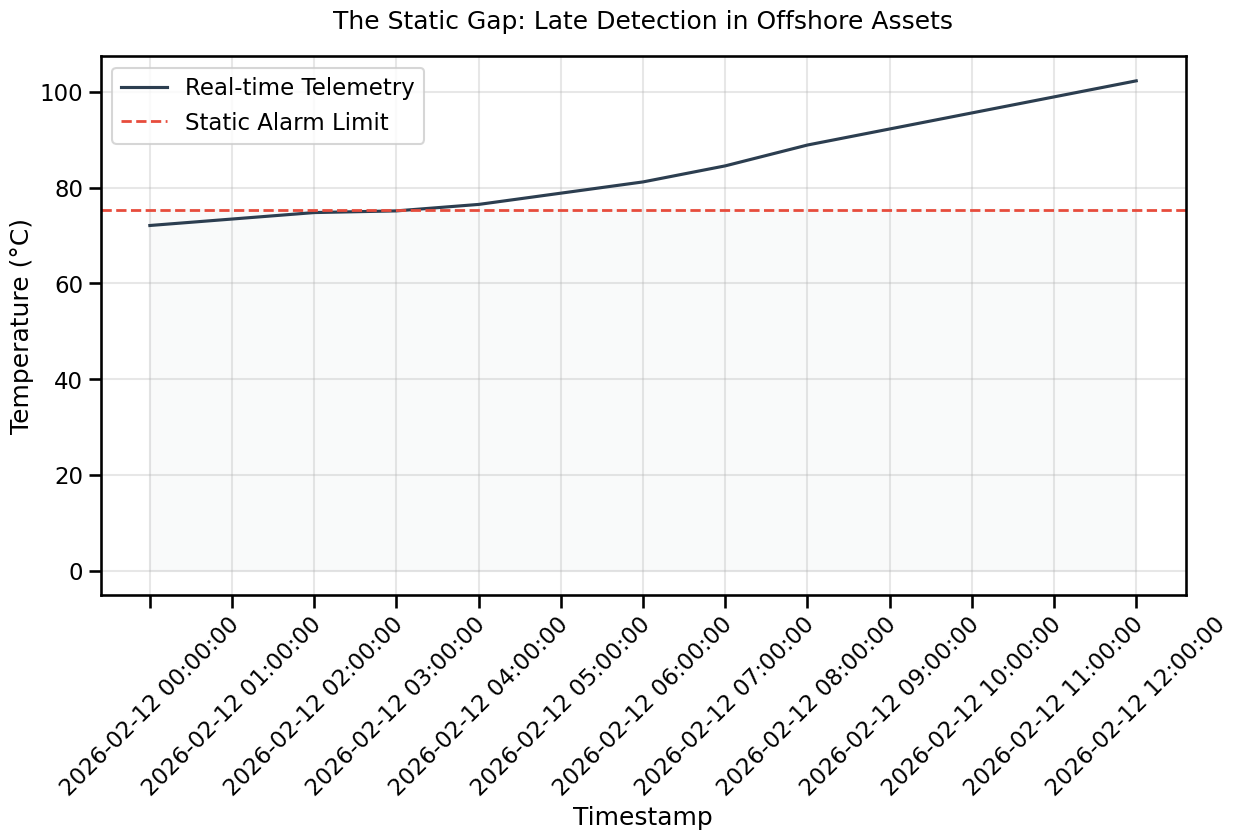

🔴 Result: The static model ignores the first 8 hours of critical temperature drift.


In [2]:
rt_df = pd.read_csv('../data/realtime_rig_telemetry.csv')

plt.figure(figsize=(14, 7))
plt.plot(rt_df['timestamp'], rt_df['temperature'], color='#2c3e50', label='Real-time Telemetry')
plt.axhline(y=temp_limit, color='#e74c3c', linestyle='--', linewidth=2, label='Static Alarm Limit')
plt.fill_between(rt_df['timestamp'], 0, temp_limit, color='#ecf0f1', alpha=0.3)

plt.title("The Static Gap: Late Detection in Offshore Assets", fontsize=18, pad=20)
plt.ylabel("Temperature (°C)")
plt.xlabel("Timestamp")
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white')
plt.grid(alpha=0.3)
plt.show()

print("🔴 Result: The static model ignores the first 8 hours of critical temperature drift.")